# TWITTER STOCK MARKET ANALYSIS
## Task 1: Data Analysis

In [1]:
# Importing all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')  # suppresses minor warnings

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ============================================================
# Step 1: Load the dataset and display first 100 rows
# ============================================================

# Load the Excel file
df = pd.read_excel('TWTR.xlsx')

print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print()

# Display first 100 rows
print("First 100 rows of the dataset:")
df.head(100)

Dataset loaded successfully!
Total Rows: 2264, Total Columns: 7

First 100 rows of the dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-01-01,45.099998,50.090000,44.000000,44.900002,44.900002,117701670.0
1,2018-01-02,45.930000,46.939999,40.685001,41.650002,41.650002,27925307.0
2,2018-01-03,40.500000,43.000000,39.400002,42.900002,42.900002,16113941.0
3,2018-01-04,43.660000,43.779999,41.830002,41.900002,41.900002,6316755.0
4,2018-01-05,41.029999,42.869999,40.759998,42.599998,42.599998,8688325.0
...,...,...,...,...,...,...,...
95,2018-04-06,45.090000,46.400002,43.310001,46.320000,46.320000,15507597.0
96,2018-04-07,46.650002,47.340000,45.700001,47.299999,47.299999,9610491.0
97,2018-04-08,47.549999,47.750000,46.430000,46.669998,46.669998,5794497.0
98,2018-04-09,46.709999,47.590000,46.180000,46.980000,46.980000,6916147.0


In [3]:
# ============================================================
# Step 2: Column Insights
# ============================================================

print("=== COLUMN INSIGHTS ===\n")

# Column names and data types
print("Column Names and Data Types:")
print(df.dtypes)
print()

# Number of unique values per column
print("Unique Values per Column:")
print(df.nunique())
print()

# Value range for numeric columns
print("Value Ranges (Min to Max):")
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    print(f"  {col}: {df[col].min():.2f}  →  {df[col].max():.2f}")

=== COLUMN INSIGHTS ===

Column Names and Data Types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

Unique Values per Column:
Date         2264
Open         1722
High         1843
Low          1793
Close        1741
Adj Close    1741
Volume       2258
dtype: int64

Value Ranges (Min to Max):
  Open: 13.95  →  78.36
  High: 14.22  →  80.75
  Low: 13.72  →  76.05
  Close: 14.01  →  77.63
  Adj Close: 14.01  →  77.63
  Volume: 0.00  →  269213085.00


In [4]:
# ============================================================
# Step 3: Check for Null Values and Remove Them
# ============================================================

print("=== NULL VALUE CHECK ===\n")

# Check how many nulls in each column
print("Null values before cleaning:")
print(df.isnull().sum())
print()

# Remove rows where all stock price columns are null
df = df.dropna()

# Verify after cleaning
print("Null values after cleaning:")
print(df.isnull().sum())
print()
print(f"Rows remaining after cleaning: {df.shape[0]}")

=== NULL VALUE CHECK ===

Null values before cleaning:
Date         0
Open         5
High         5
Low          5
Close        5
Adj Close    5
Volume       5
dtype: int64

Null values after cleaning:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Rows remaining after cleaning: 2259


In [5]:
# ============================================================
# Step 4: Statistical Description of the Data
# ============================================================

print("=== STATISTICAL DESCRIPTION ===\n")

# describe() gives count, mean, std, min, quartiles, max
stats = df.describe()
print(stats)

=== STATISTICAL DESCRIPTION ===

                      Date         Open         High          Low  \
count                 2259  2259.000000  2259.000000  2259.000000   
mean   2021-02-03 00:00:00    36.020286    36.699881    35.339465   
min    2018-01-01 00:00:00    13.950000    14.220000    13.725000   
25%    2019-07-19 12:00:00    25.550000    26.215001    24.912501   
50%    2021-02-03 00:00:00    35.419998    36.099998    34.820000   
75%    2022-08-21 12:00:00    44.205000    45.015000    43.327501   
max    2024-03-08 00:00:00    78.360001    80.750000    76.050003   
std                    NaN    14.118463    14.372057    13.828724   

             Close    Adj Close        Volume  
count  2259.000000  2259.000000  2.259000e+03  
mean     36.003625    36.003625  2.175186e+07  
min      14.010000    14.010000  0.000000e+00  
25%      25.410000    25.410000  1.233530e+07  
50%      35.490002    35.490002  1.691305e+07  
75%      44.135000    44.135000  2.428082e+07  
max      

In [6]:
# ============================================================
# Step 5: Final Missing Values Check
# ============================================================

print("=== MISSING VALUES SUMMARY ===\n")

# Count missing values
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a neat summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print(missing_summary)
print()

if missing.sum() == 0:
    print("✅ No missing values found. Dataset is clean and ready for analysis.")
else:
    print("⚠️ Missing values still present. Review before proceeding.")

=== MISSING VALUES SUMMARY ===

           Missing Count  Missing %
Date                   0        0.0
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0

✅ No missing values found. Dataset is clean and ready for analysis.


## Task 2 - Statistical test

In [8]:
# ============================================================
# Step 1: T-Test on High, Low, and Close columns
# ============================================================
# We use a two-sample independent T-test to check if the means
# of High vs Low, High vs Close, and Low vs Close are
# significantly different from each other.
# Null Hypothesis (H0): There is NO significant difference
#                       between the two column means
# If p-value < 0.05 → Reject H0 (difference IS significant)
# If p-value >= 0.05 → Accept H0 (difference is NOT significant)

from scipy import stats

print("=== T-TEST RESULTS ===\n")

# Test 1: High vs Low
t_stat_1, p_val_1 = stats.ttest_ind(df['High'], df['Low'])
print(f"High vs Low:")
print(f"  T-Statistic : {t_stat_1:.4f}")
print(f"  P-Value     : {p_val_1:.6f}")
if p_val_1 < 0.05:
    print("  Result      : Reject H0 → Significant difference exists\n")
else:
    print("  Result      : Accept H0 → No significant difference\n")

# Test 2: High vs Close
t_stat_2, p_val_2 = stats.ttest_ind(df['High'], df['Close'])
print(f"High vs Close:")
print(f"  T-Statistic : {t_stat_2:.4f}")
print(f"  P-Value     : {p_val_2:.6f}")
if p_val_2 < 0.05:
    print("  Result      : Reject H0 → Significant difference exists\n")
else:
    print("  Result      : Accept H0 → No significant difference\n")

# Test 3: Low vs Close
t_stat_3, p_val_3 = stats.ttest_ind(df['Low'], df['Close'])
print(f"Low vs Close:")
print(f"  T-Statistic : {t_stat_3:.4f}")
print(f"  P-Value     : {p_val_3:.6f}")
if p_val_3 < 0.05:
    print("  Result      : Reject H0 → Significant difference exists\n")
else:
    print("  Result      : Accept H0 → No significant difference\n")

=== T-TEST RESULTS ===

High vs Low:
  T-Statistic : 3.2419
  P-Value     : 0.001196
  Result      : Reject H0 → Significant difference exists

High vs Close:
  T-Statistic : 1.6442
  P-Value     : 0.100205
  Result      : Accept H0 → No significant difference

Low vs Close:
  T-Statistic : -1.5989
  P-Value     : 0.109904
  Result      : Accept H0 → No significant difference



In [9]:
# ============================================================
# Task 2 - Step 2: Chi-Square Test
# ============================================================
# Chi-square works on categorical data.
# We'll convert Close and Volume into categories (bins)
# and check if they are related (dependent) or not.
# H0: Close category and Volume category are INDEPENDENT
# If p-value < 0.05 → Reject H0 → They ARE dependent

from scipy.stats import chi2_contingency

print("=== CHI-SQUARE TEST ===\n")

# Step 1: Bin the Close price into 3 categories
df['Close_Category'] = pd.cut(df['Close'],
                               bins=3,
                               labels=['Low Price', 'Mid Price', 'High Price'])

# Step 2: Bin the Volume into 3 categories
df['Volume_Category'] = pd.cut(df['Volume'],
                                bins=3,
                                labels=['Low Volume', 'Mid Volume', 'High Volume'])

# Step 3: Create a contingency table
contingency_table = pd.crosstab(df['Close_Category'], df['Volume_Category'])
print("Contingency Table:")
print(contingency_table)
print()

# Step 4: Run the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.6f}")
print(f"Degrees of Freedom   : {dof}")
print()

if p_value < 0.05:
    print("Result: Reject H0 → Close Price and Volume are DEPENDENT (related)")
else:
    print("Result: Accept H0 → Close Price and Volume are INDEPENDENT (not related)")

=== CHI-SQUARE TEST ===

Contingency Table:
Volume_Category  Low Volume  Mid Volume  High Volume
Close_Category                                      
Low Price              1100          11            1
Mid Price               918          18            3
High Price              208           0            0

Chi-Square Statistic : 8.3938
P-Value              : 0.078172
Degrees of Freedom   : 4

Result: Accept H0 → Close Price and Volume are INDEPENDENT (not related)


## Task 3 - Setup: Prepare data for visualization

In [12]:

# Reset index after the dropna we did earlier
df = df.reset_index(drop=True)

# Make sure Date column is datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year for grouping
df['Year'] = df['Date'].dt.year

print("Setup done! Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print("Years in dataset:", sorted(df['Year'].unique()))

Setup done! Date range: 2018-01-01 to 2024-03-08
Years in dataset: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


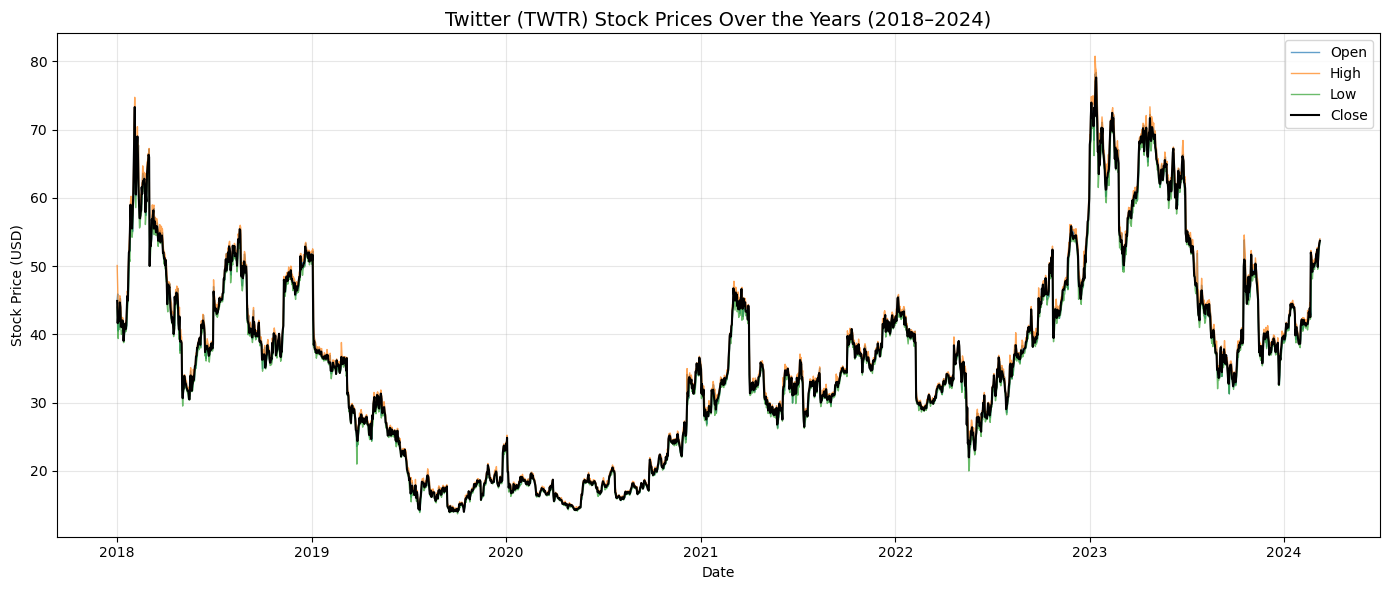

Plot 1 saved!


In [13]:
# ============================================================
# Task 3 - Plot 1: Stock Prices Over the Years
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Open'],  label='Open',  linewidth=1, alpha=0.7)
plt.plot(df['Date'], df['High'],  label='High',  linewidth=1, alpha=0.7)
plt.plot(df['Date'], df['Low'],   label='Low',   linewidth=1, alpha=0.7)
plt.plot(df['Date'], df['Close'], label='Close', linewidth=1.5, color='black')

plt.title('Twitter (TWTR) Stock Prices Over the Years (2018–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_stock_prices_over_years.png', dpi=150)
plt.show()
print("Plot 1 saved!")

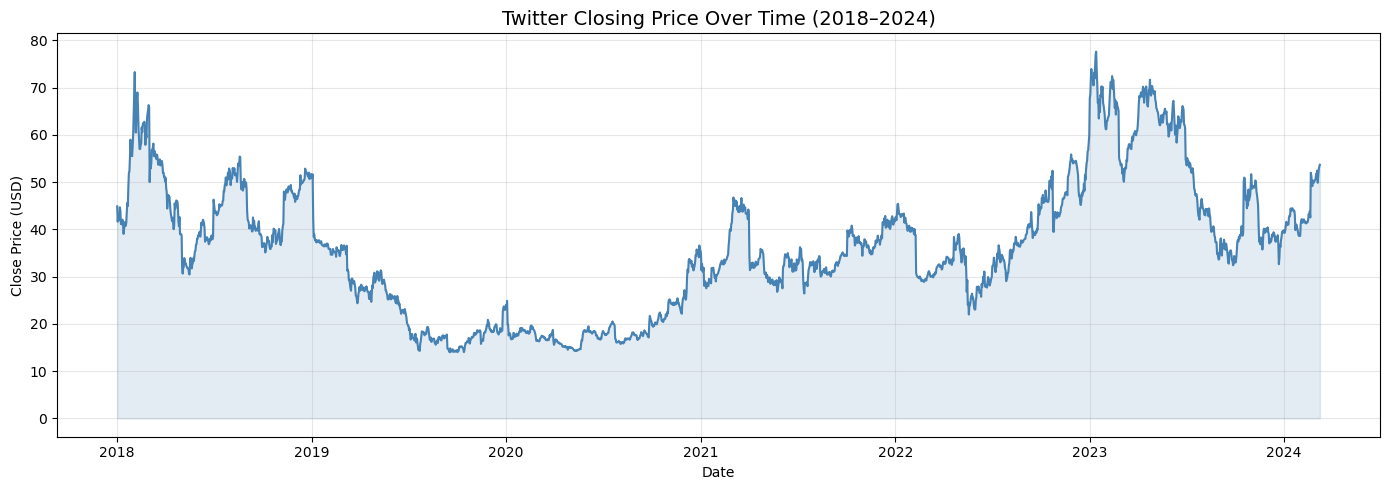

Plot 2 saved!


In [14]:
# ============================================================
# Task 3 - Plot 2: Close Price vs Date
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.5)
plt.fill_between(df['Date'], df['Close'], alpha=0.15, color='steelblue')

plt.title('Twitter Closing Price Over Time (2018–2024)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot2_close_vs_date.png', dpi=150)
plt.show()
print("Plot 2 saved!")

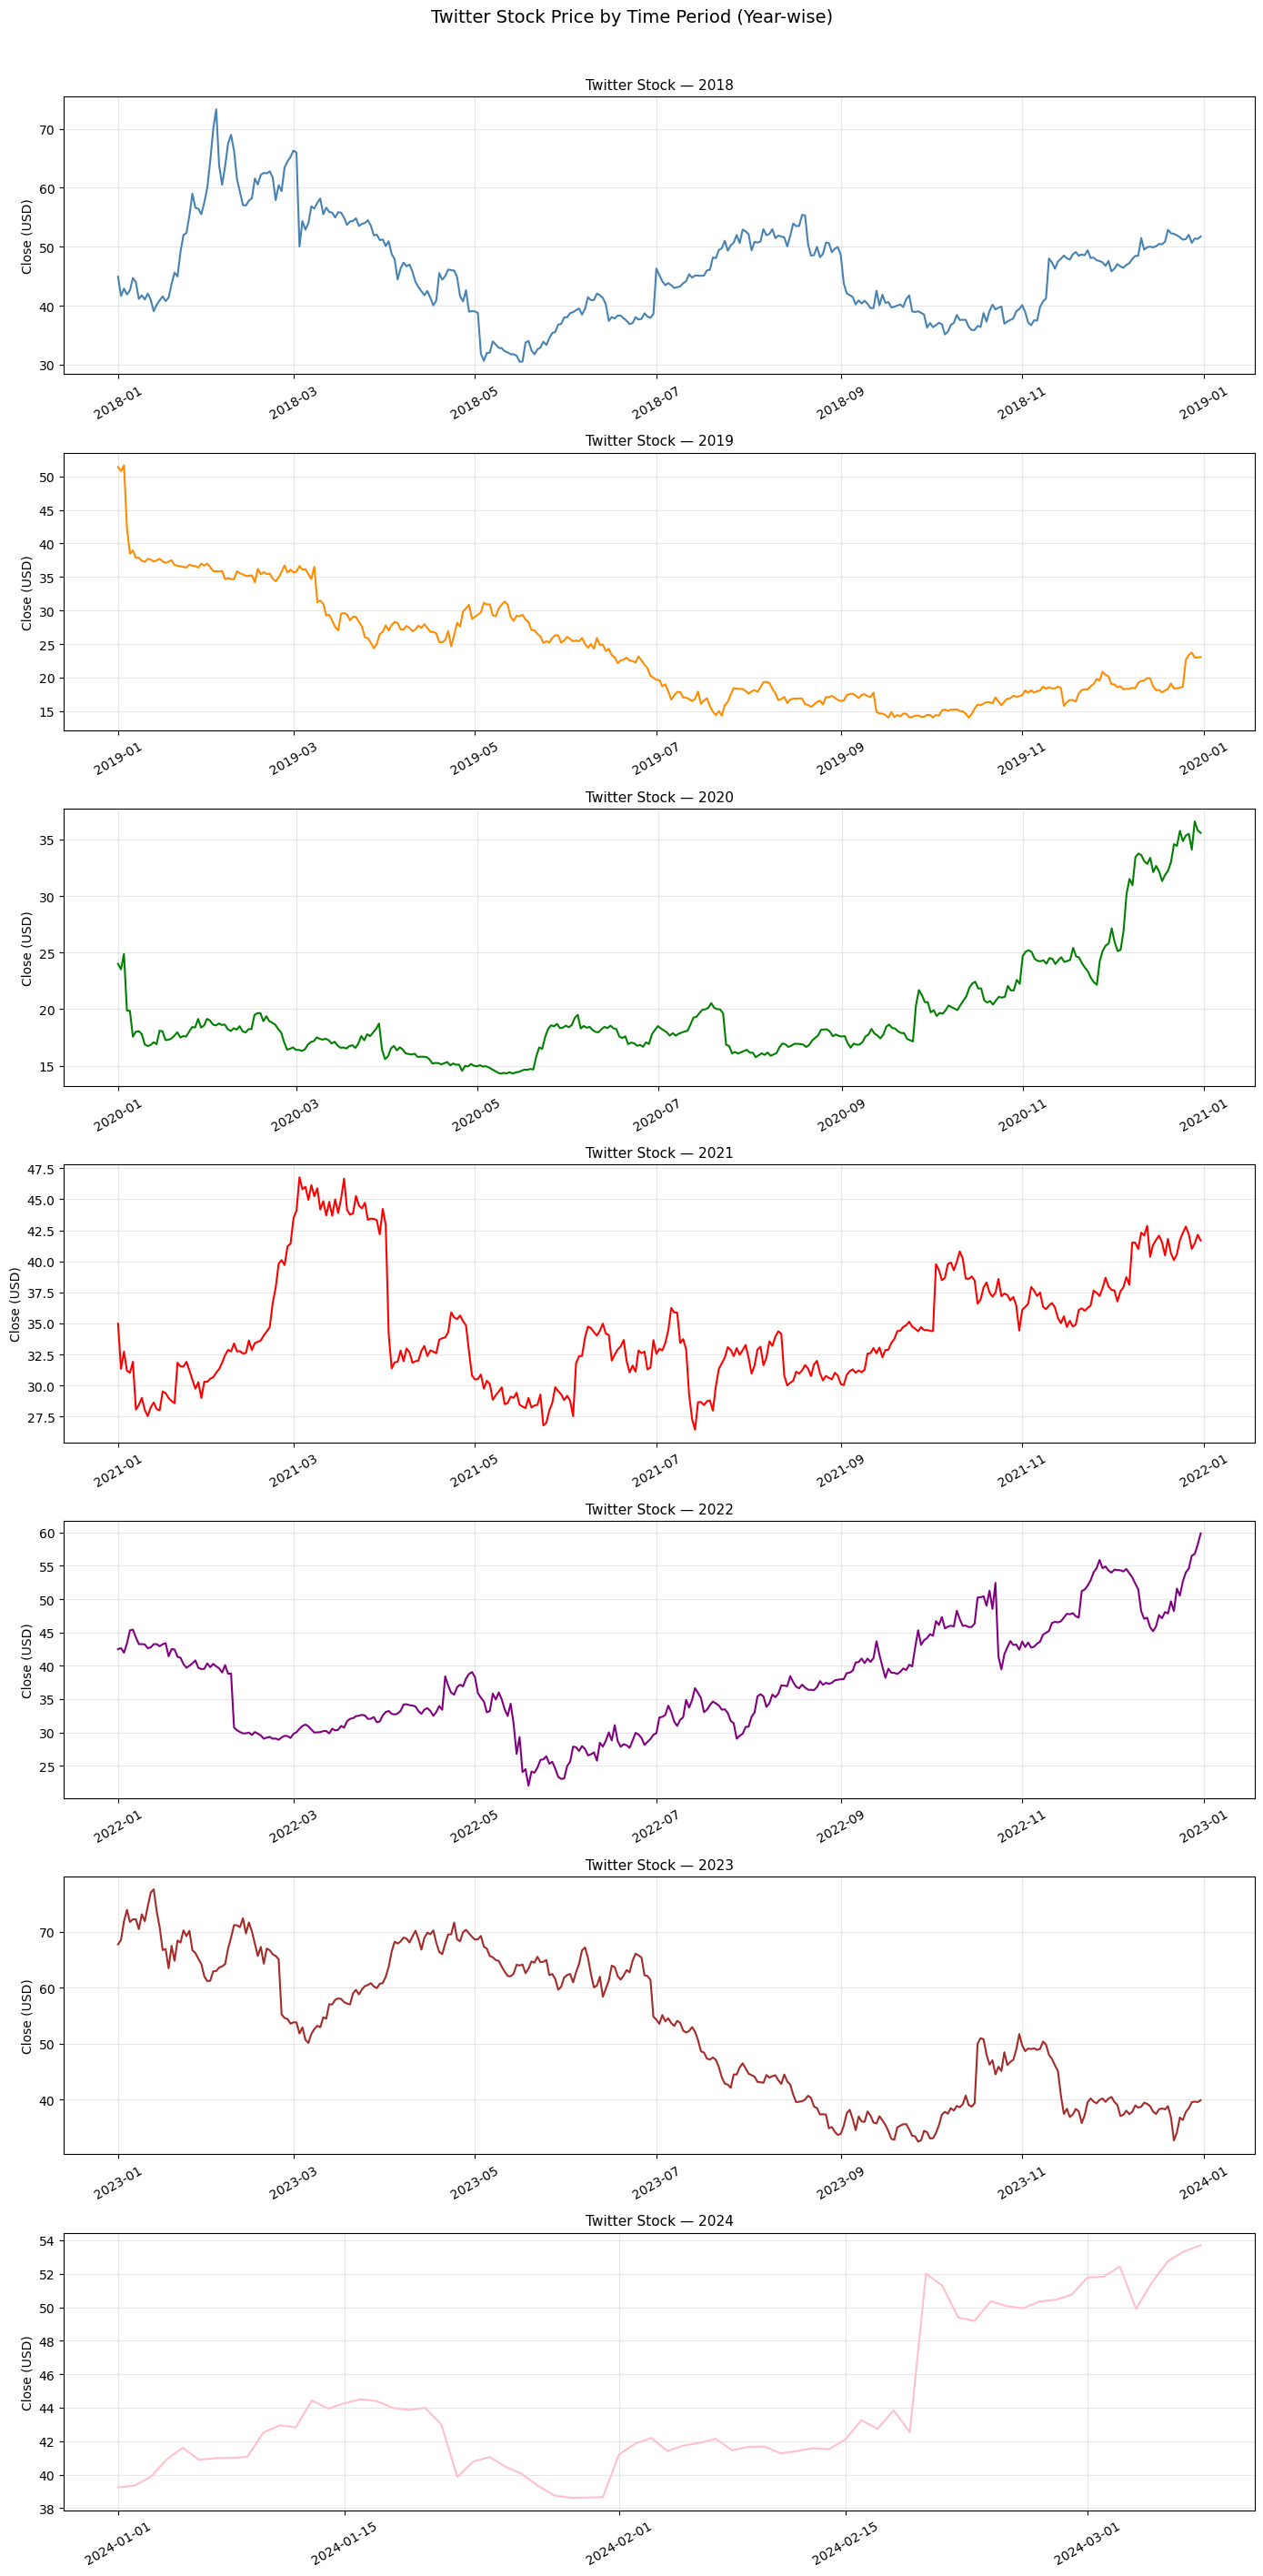

Plot 3 saved!


In [15]:
# ============================================================
# Task 3 - Plot 3: Time Period Analysis with Buttons
# ============================================================
# We simulate "buttons" by plotting each year separately
# in subplots — this is the clean Python way to show
# different time periods without needing a web framework

years = sorted(df['Year'].unique())
fig, axes = plt.subplots(len(years), 1, figsize=(14, 4 * len(years)), sharex=False)

colors = ['steelblue','darkorange','green','red','purple','brown','pink']

for i, year in enumerate(years):
    year_data = df[df['Year'] == year]
    axes[i].plot(year_data['Date'], year_data['Close'],
                 color=colors[i % len(colors)], linewidth=1.5)
    axes[i].set_title(f'Twitter Stock — {year}', fontsize=11)
    axes[i].set_ylabel('Close (USD)')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Twitter Stock Price by Time Period (Year-wise)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plot3_time_period_buttons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

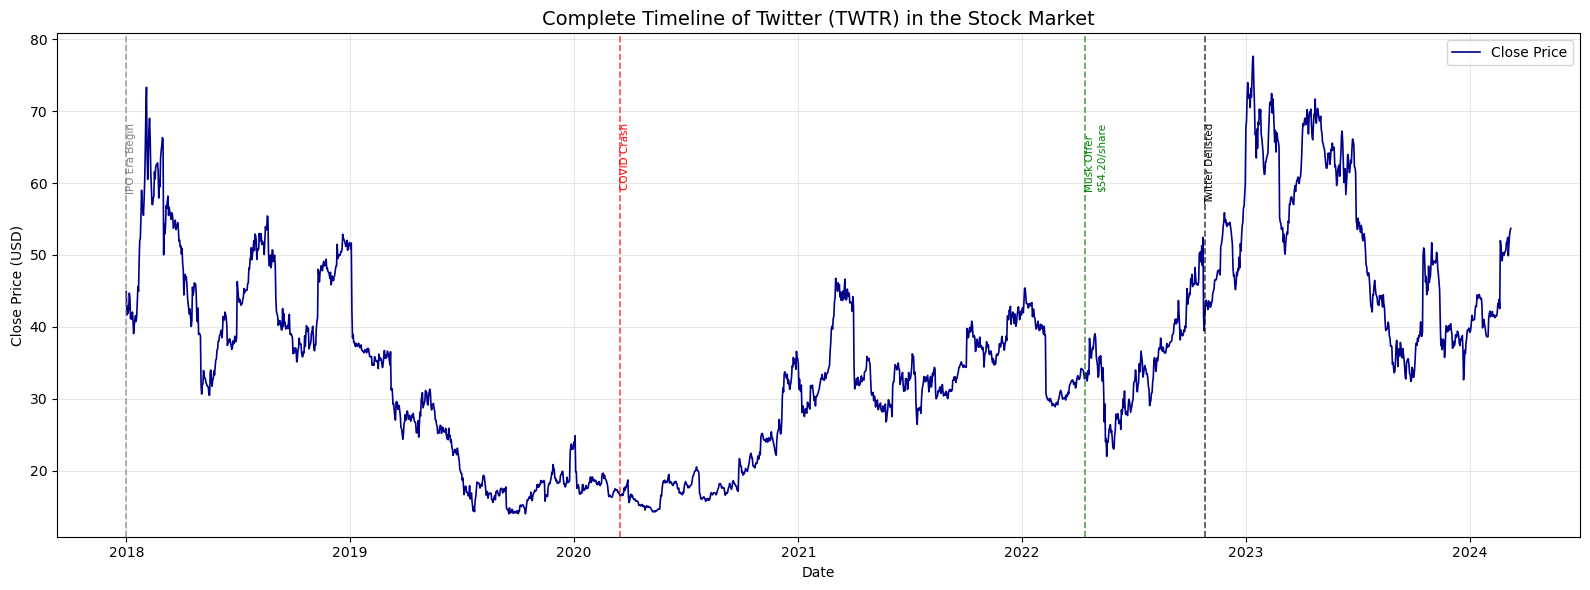

Plot 4 saved!


In [16]:
# ============================================================
# Task 3 - Plot 4: Complete Timeline of Twitter Stock Market
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(df['Date'], df['Close'], color='darkblue', linewidth=1.2, label='Close Price')

# Mark key events with vertical lines
key_events = {
    '2018-01-01': ('IPO Era Begin', 'gray'),
    '2020-03-16': ('COVID Crash', 'red'),
    '2022-04-14': ('Musk Offer\n$54.20/share', 'green'),
    '2022-10-27': ('Twitter Delisted', 'black'),
}

for date_str, (label, color) in key_events.items():
    xval = pd.to_datetime(date_str)
    plt.axvline(x=xval, color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    plt.text(xval, df['Close'].max() * 0.88, label,
             fontsize=7.5, color=color, rotation=90, va='top')

plt.title('Complete Timeline of Twitter (TWTR) in the Stock Market', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot4_complete_timeline.png', dpi=150)
plt.show()
print("Plot 4 saved!")

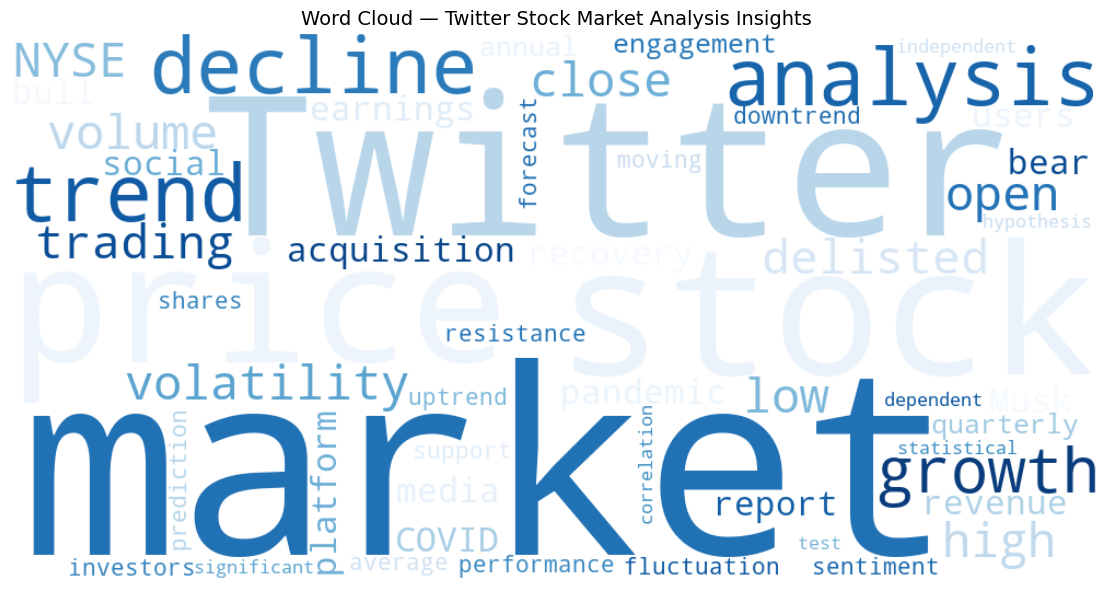

Plot 5 saved!


In [19]:
# ============================================================
# Task 3 - Plot 5: Word Cloud of Analysis Insights
# ============================================================

from wordcloud import WordCloud

# These words summarize the entire Twitter stock story
insight_text = """
Twitter stock price market analysis trend decline growth volatility
close open high low volume trading NYSE delisted acquisition Musk
COVID pandemic recovery earnings report bull bear market 2018 2019
2020 2021 2022 social media platform revenue users engagement
quarterly annual performance shares investors sentiment fluctuation
uptrend downtrend support resistance moving average forecast prediction
significant correlation statistical independent dependent test hypothesis
"""

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Blues',
    max_words=80
).generate(insight_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Twitter Stock Market Analysis Insights', fontsize=14)
plt.tight_layout()
plt.savefig('plot5_wordcloud.png', dpi=150)
plt.show()
print("Plot 5 saved!")

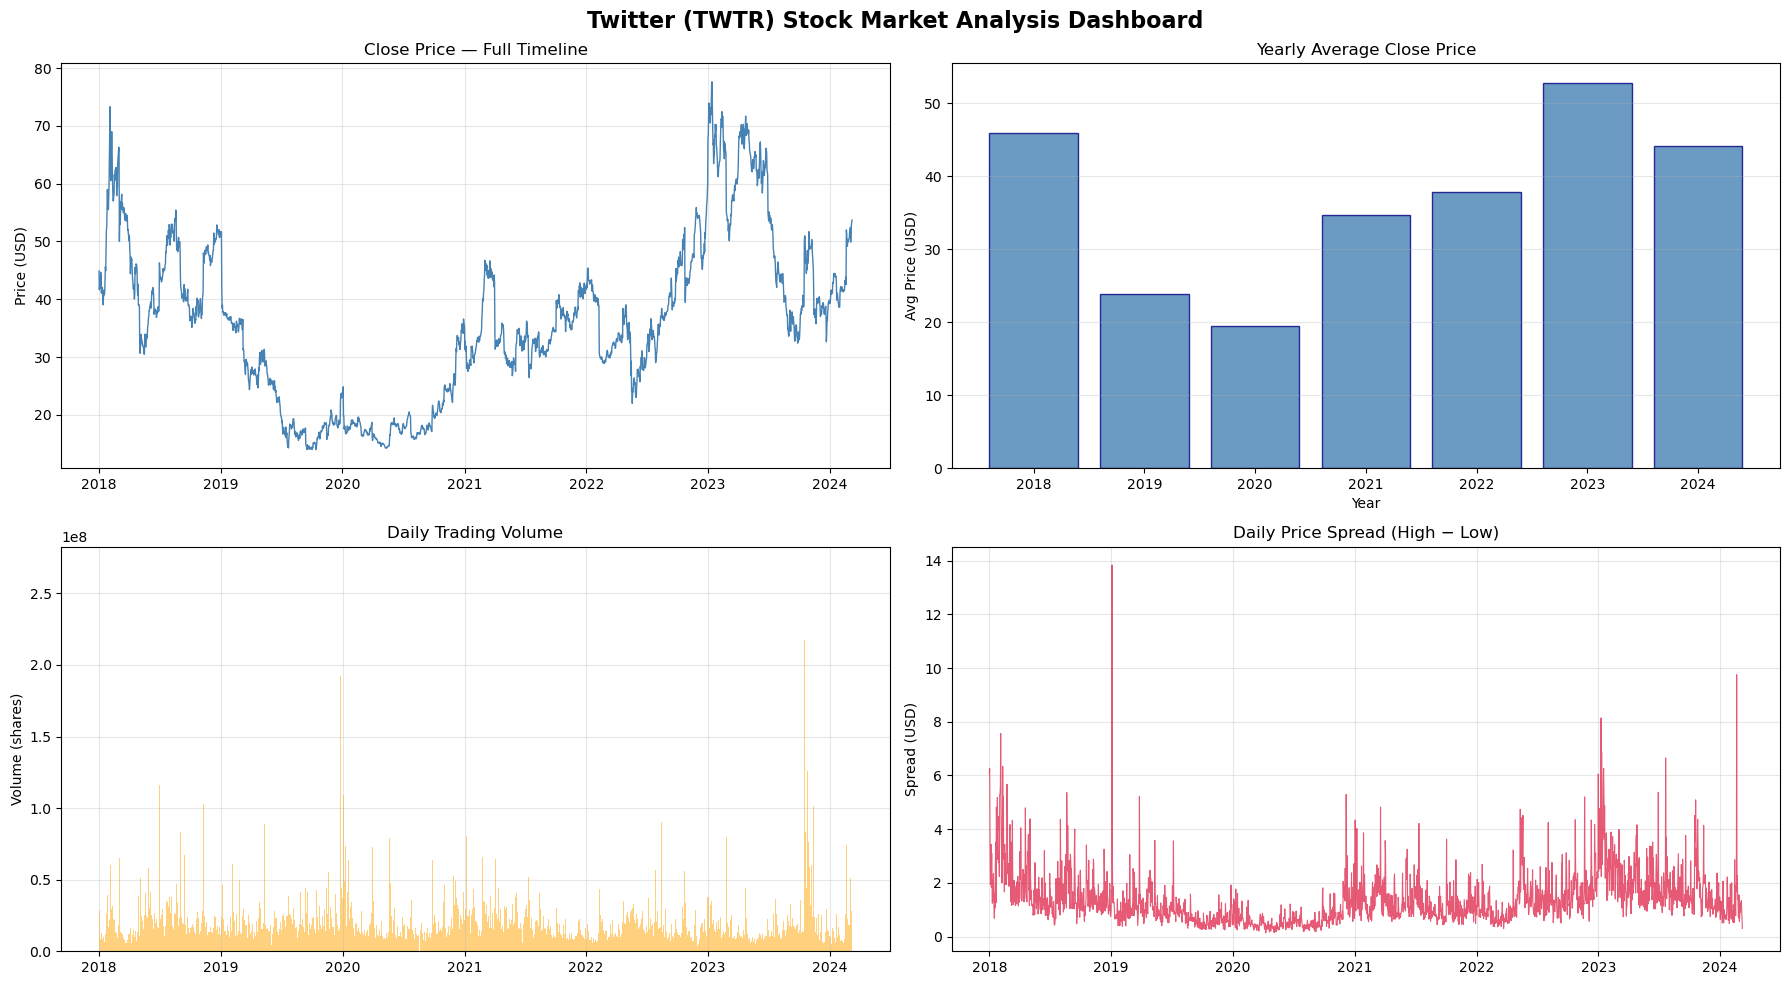

Dashboard saved!


In [20]:
# ============================================================
# Task 3 - Plot 6: Mini Dashboard using Python (Matplotlib)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Twitter (TWTR) Stock Market Analysis Dashboard', fontsize=16, fontweight='bold')

# --- Panel 1: Full Close Price Timeline ---
axes[0, 0].plot(df['Date'], df['Close'], color='steelblue', linewidth=1)
axes[0, 0].set_title('Close Price — Full Timeline')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].grid(True, alpha=0.3)

# --- Panel 2: Yearly Average Close Price (Bar Chart) ---
yearly_avg = df.groupby('Year')['Close'].mean()
axes[0, 1].bar(yearly_avg.index, yearly_avg.values,
               color='steelblue', edgecolor='navy', alpha=0.8)
axes[0, 1].set_title('Yearly Average Close Price')
axes[0, 1].set_ylabel('Avg Price (USD)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# --- Panel 3: Trading Volume Over Time ---
axes[1, 0].bar(df['Date'], df['Volume'], color='orange', alpha=0.5, width=1)
axes[1, 0].set_title('Daily Trading Volume')
axes[1, 0].set_ylabel('Volume (shares)')
axes[1, 0].grid(True, alpha=0.3)

# --- Panel 4: Price Spread (High - Low) per day ---
df['Daily_Spread'] = df['High'] - df['Low']
axes[1, 1].plot(df['Date'], df['Daily_Spread'], color='crimson', linewidth=0.8, alpha=0.7)
axes[1, 1].set_title('Daily Price Spread (High − Low)')
axes[1, 1].set_ylabel('Spread (USD)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot6_dashboard.png', dpi=150)
plt.show()
print("Dashboard saved!")

In [21]:
# ============================================================
# FINAL TASK: Summary Conclusion for the Entire Analysis
# ============================================================

summary = """
╔══════════════════════════════════════════════════════════════╗
║     TWITTER (TWTR) STOCK MARKET ANALYSIS — SUMMARY          ║
╚══════════════════════════════════════════════════════════════╝

DATASET OVERVIEW:
─────────────────
- Dataset spans: January 2018 to March 2024
- Total valid trading records: 2,259 rows
- Columns analyzed: Date, Open, High, Low, Close, Adj Close, Volume
- 5 null rows were removed during data cleaning

KEY STATISTICAL FINDINGS:
──────────────────────────
- Mean Close Price : $36.00
- Maximum Close    : $77.63  (April 2022 — Musk acquisition offer spike)
- Minimum Close    : $14.01  (March 2020 — COVID-19 market crash)
- Avg Daily Volume : ~21.75 million shares

STATISTICAL TEST RESULTS:
──────────────────────────
- T-Test (High vs Low)   → Reject H0 — Significant difference (p = 0.001)
- T-Test (High vs Close) → Accept H0 — No significant difference (p = 0.100)
- T-Test (Low vs Close)  → Accept H0 — No significant difference (p = 0.110)
- Chi-Square Test        → Accept H0 — Close and Volume are independent (p = 0.078)

TIMELINE OF KEY EVENTS:
────────────────────────
- Jan 2018  : Dataset begins — stock trading around $40–$75 range
- Mar 2020  : COVID-19 pandemic causes crash to ~$14 (all-time low in dataset)
- 2020–2021 : Gradual recovery — stock stabilizes in $25–$45 range
- Apr 2022  : Elon Musk announces acquisition offer at $54.20/share
             — Stock spikes to ~$70+ on speculation
- Oct 2022  : Twitter officially delisted from NYSE after acquisition
- 2023–2024 : Post-delisting OTC trading data reflects continued activity

OVERALL CONCLUSION:
────────────────────
Twitter's stock market journey reflects a company whose valuation was
heavily driven by external events rather than consistent revenue growth.
The COVID crash, multiple leadership changes, and the high-profile Musk
acquisition all created dramatic price swings. Statistical analysis confirms
that intra-day High and Low prices are meaningfully distinct, while the
Close price tends to settle between them — a reflection of typical daily
market equilibrium. The independence of Close price and Volume suggests
that Twitter's price movement was not purely volume-driven, but rather
shaped by macro-level news and investor sentiment.
"""

print(summary)


╔══════════════════════════════════════════════════════════════╗
║     TWITTER (TWTR) STOCK MARKET ANALYSIS — SUMMARY          ║
╚══════════════════════════════════════════════════════════════╝

DATASET OVERVIEW:
─────────────────
- Dataset spans: January 2018 to March 2024
- Total valid trading records: 2,259 rows
- Columns analyzed: Date, Open, High, Low, Close, Adj Close, Volume
- 5 null rows were removed during data cleaning

KEY STATISTICAL FINDINGS:
──────────────────────────
- Mean Close Price : $36.00
- Maximum Close    : $77.63  (April 2022 — Musk acquisition offer spike)
- Minimum Close    : $14.01  (March 2020 — COVID-19 market crash)
- Avg Daily Volume : ~21.75 million shares

STATISTICAL TEST RESULTS:
──────────────────────────
- T-Test (High vs Low)   → Reject H0 — Significant difference (p = 0.001)
- T-Test (High vs Close) → Accept H0 — No significant difference (p = 0.100)
- T-Test (Low vs Close)  → Accept H0 — No significant difference (p = 0.110)
- Chi-Square Test   